In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
import pandas as pd

# Load CSV
labels = pd.read_csv(r"C:\Users\rohini.patil\Desktop\Bits on Assignments\Assignment 5\part_2_cnn_computer_vision-20260507T105202Z-3-001\part_2_cnn_computer_vision\labels.csv")

# Show first rows
print(labels.head())

# Show columns
print("\nColumns:")
print(labels.columns)

                       filename   class
0  images/normal/normal_001.png  normal
1  images/normal/normal_002.png  normal
2  images/normal/normal_003.png  normal
3  images/normal/normal_004.png  normal
4  images/normal/normal_005.png  normal

Columns:
Index(['filename', 'class'], dtype='str')


# Task 1: Problem Identification

## Selected Problem Type:
Image Classification

### Explanation:
This dataset contains images of manufacturing product surfaces categorized into four classes:
- normal
- scratch
- dent
- stain

Each image is assigned a single label representing the type of defect present on the product surface. The objective is to train a CNN model that can classify an input image into one of these predefined categories.

This is an image classification problem because the model predicts one class label for the entire image rather than detecting object locations or performing pixel-level segmentation.

### Why Other Problem Types Are Not Suitable:
- Object Detection: The dataset does not contain bounding boxes to locate defects.
- Semantic Segmentation: The dataset does not contain pixel-wise masks.
- Instance Segmentation: The dataset does not contain separate instance masks for defects.

### Conclusion:
Therefore, the dataset represents an Image Classification problem.

Classes in Dataset:
['dent', 'normal', 'scratch', 'stain']

Number of Classes: 4

Number of Images per Class:
dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images

Sample Image Dimension for dent: (96, 96)

Sample Image Dimension for normal: (96, 96)

Sample Image Dimension for scratch: (96, 96)

Sample Image Dimension for stain: (96, 96)


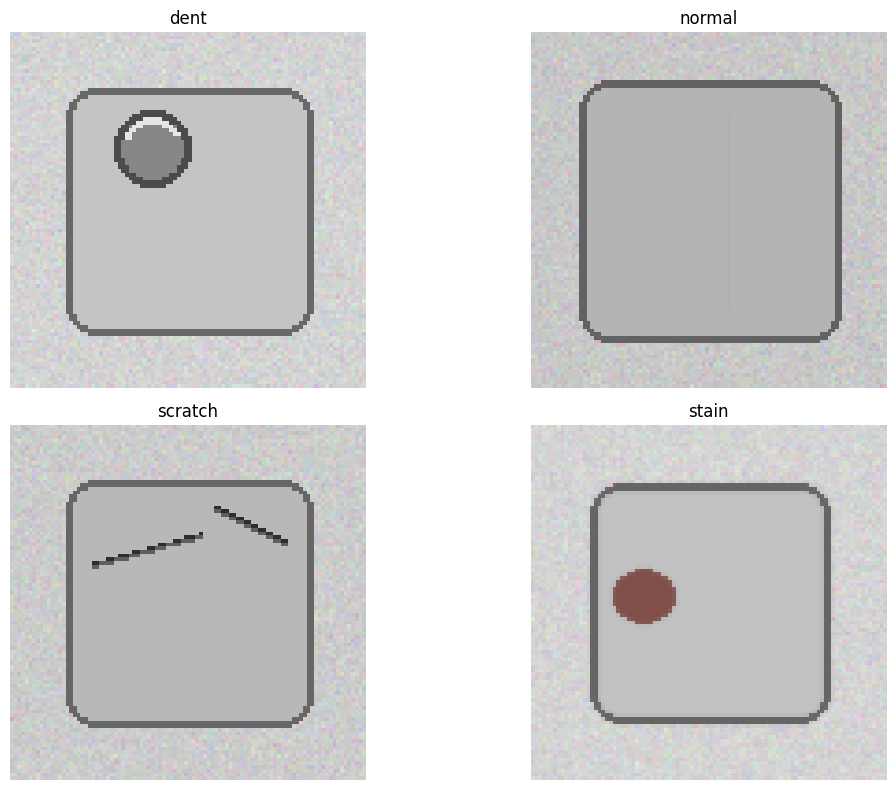


Dataset Imbalance Analysis:
Dataset is balanced.


In [2]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Correct dataset path
dataset_path = r"C:\Users\rohini.patil\Desktop\Bits on Assignments\Assignment 5\part_2_cnn_computer_vision-20260507T105202Z-3-001\part_2_cnn_computer_vision\images"

# Get only folder names (classes)
classes = [cls for cls in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, cls))]

# Display class names
print("Classes in Dataset:")
print(classes)

# Number of classes
print("\nNumber of Classes:", len(classes))

# Count images per class
print("\nNumber of Images per Class:")

class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    images = os.listdir(class_path)

    class_counts[cls] = len(images)

    print(f"{cls}: {len(images)} images")

# Display sample image from each class
plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    print(f"\nSample Image Dimension for {cls}: {img.size}")

    plt.subplot(2, 2, i + 1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis('off')

plt.tight_layout()

plt.show()

# Dataset imbalance analysis
print("\nDataset Imbalance Analysis:")

max_images = max(class_counts.values())

min_images = min(class_counts.values())

if max_images == min_images:
    print("Dataset is balanced.")
else:
    print("Dataset is imbalanced.")

# Task 2: Dataset Exploration

## Number of Classes
The dataset contains 4 classes:
- normal
- scratch
- dent
- stain

## Number of Images per Class
The number of images in each class was analyzed using Python and displayed programmatically.

## Sample Images
Sample images from each class were displayed to understand the visual differences between defects.

## Image Dimensions
The dimensions of sample images were checked using the PIL library.

## Dataset Imbalance
The dataset was analyzed for class imbalance by comparing the number of images in each category. If all classes contain nearly equal images, the dataset is considered balanced; otherwise, it is imbalanced.

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset path
dataset_path = r"C:\Users\rohini.patil\Desktop\Bits on Assignments\Assignment 5\part_2_cnn_computer_vision-20260507T105202Z-3-001\part_2_cnn_computer_vision\images"

# Image size
IMG_HEIGHT = 128
IMG_WIDTH = 128

# Batch size
BATCH_SIZE = 32

# Data augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values
    validation_split=0.2,     # 80% train, 20% test
    rotation_range=20,        # Augmentation
    zoom_range=0.2,
    horizontal_flip=True
)

# Training dataset
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),   # Resize images
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Testing dataset
test_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Display dataset information
print("\nClass Labels:")
print(train_data.class_indices)

print("\nTraining Samples:")
print(train_data.samples)

print("\nTesting Samples:")
print(test_data.samples)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.

Class Labels:
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}

Training Samples:
384

Testing Samples:
96


# Task 3: Image Preprocessing

## Objective
The image dataset is preprocessed before training the CNN model.

The preprocessing steps include:
- Resizing images to a fixed size
- Normalizing pixel values
- Splitting dataset into training and testing sets
- Applying image augmentation techniques

Image preprocessing improves model performance and helps the CNN learn features efficiently.

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Create CNN Model
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128,128,3)
))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Layer
model.add(Conv2D(
    128,
    (3,3),
    activation='relu'
))

# Third Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

c:\Users\rohini.patil\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: CNN Model Creation

## Objective
A Convolutional Neural Network (CNN) model is created for image classification of manufacturing defects.

The CNN model includes:
- Convolution layers
- Activation functions
- Pooling layers
- Flatten layer
- Dense layers
- Output layer

The model is designed to classify images into four classes:
- normal
- scratch
- dent
- stain

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset Path
dataset_path = r"C:\Users\rohini.patil\Desktop\Bits on Assignments\Assignment 5\part_2_cnn_computer_vision-20260507T105202Z-3-001\part_2_cnn_computer_vision\images"

# Image dimensions
IMG_HEIGHT = 128
IMG_WIDTH = 128

# Batch size
BATCH_SIZE = 32

# Image preprocessing + augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Training dataset
train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation dataset
test_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Display information
print("Class Labels:")
print(train_data.class_indices)

print("\nTraining Samples:")
print(train_data.samples)

print("\nValidation Samples:")
print(test_data.samples)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Class Labels:
{'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}

Training Samples:
384

Validation Samples:
96


In [4]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - accuracy: 0.2448 - loss: 1.7262 - val_accuracy: 0.2500 - val_loss: 1.3856
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 689ms/step - accuracy: 0.2344 - loss: 1.3881 - val_accuracy: 0.2500 - val_loss: 1.3834
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 789ms/step - accuracy: 0.2917 - loss: 1.3785 - val_accuracy: 0.6458 - val_loss: 1.3568
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 757ms/step - accuracy: 0.3724 - loss: 1.3127 - val_accuracy: 0.5104 - val_loss: 1.2143
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 675ms/step - accuracy: 0.4948 - loss: 1.1759 - val_accuracy: 0.5312 - val_loss: 1.0385
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - accuracy: 0.4714 - loss: 1.1938 - val_accuracy: 0.6250 - val_loss: 1.1049
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 197ms/step - accuracy: 0.5078 - loss: 1.1094 - val_accuracy: 0.5521 - val_loss: 0.9196
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 562ms/step - accuracy: 0.6328 - loss: 0.9387 - val_accuracy: 

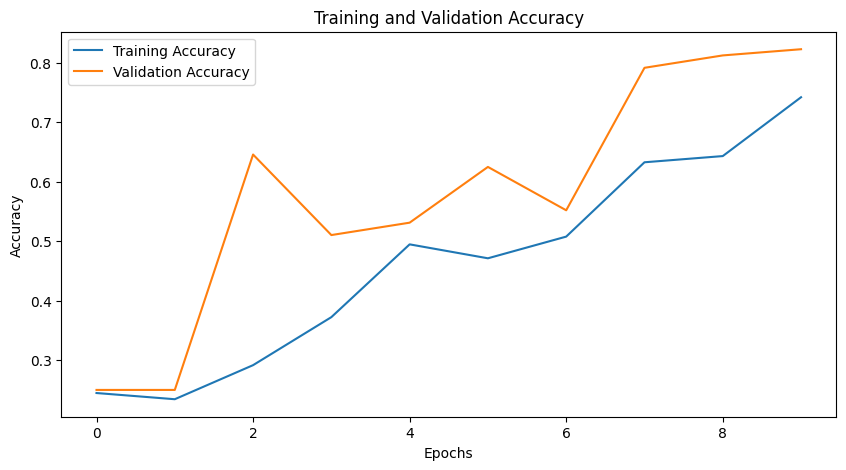

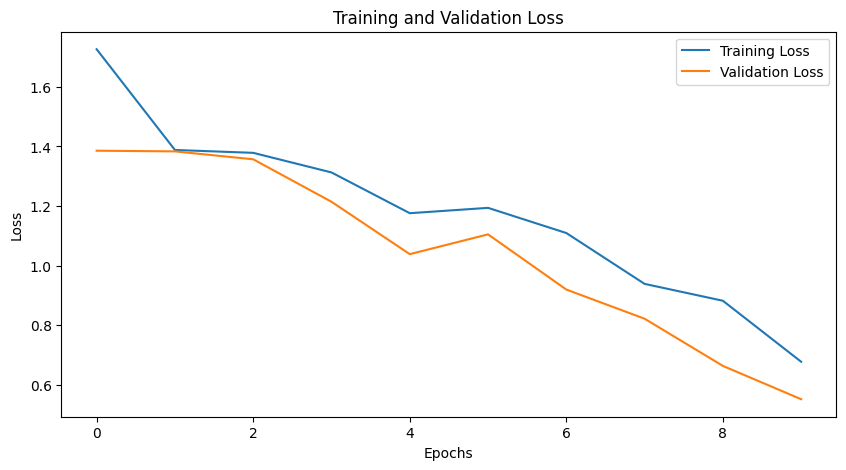

In [5]:
import matplotlib.pyplot as plt
import os

# Create results folder
os.makedirs("results", exist_ok=True)

# Accuracy Graph
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Save graph
plt.savefig("results/accuracy_loss_curves.png")

plt.show()

# Loss Graph
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [6]:
# Evaluate Model

test_loss, test_accuracy = model.evaluate(test_data)

print("Testing Accuracy:", test_accuracy)

print("Testing Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8542 - loss: 0.5421
Testing Accuracy: 0.8541666865348816
Testing Loss: 0.5420746207237244


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


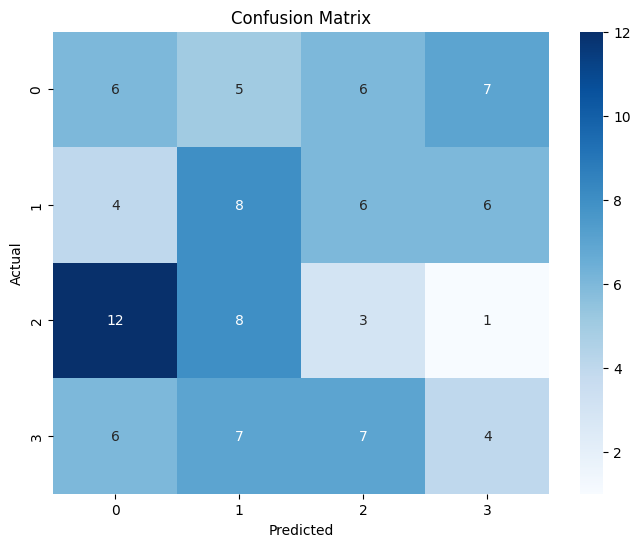


Classification Report:

              precision    recall  f1-score   support

           0       0.21      0.25      0.23        24
           1       0.29      0.33      0.31        24
           2       0.14      0.12      0.13        24
           3       0.22      0.17      0.19        24

    accuracy                           0.22        96
   macro avg       0.21      0.22      0.21        96
weighted avg       0.21      0.22      0.21        96



In [7]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Save image
plt.savefig("results/confusion_matrix.png")

plt.show()

# Classification Report
print("\nClassification Report:\n")

print(classification_report(
    true_classes,
    predicted_classes
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


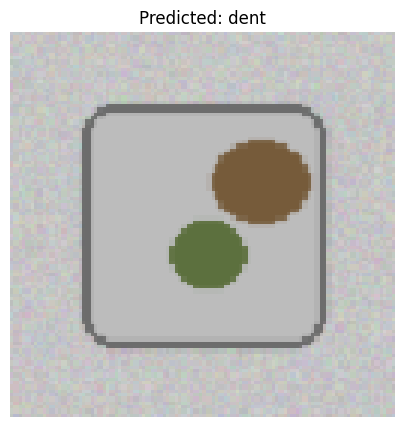

In [8]:
import random
from tensorflow.keras.preprocessing import image

# Create folder
os.makedirs("sample_predictions", exist_ok=True)

# Class names
class_names = list(train_data.class_indices.keys())

# Random class
random_class = random.choice(class_names)

class_path = os.path.join(dataset_path, random_class)

# Random image
img_name = random.choice(os.listdir(class_path))

img_path = os.path.join(class_path, img_name)

# Load image
img = image.load_img(img_path, target_size=(128,128))

# Convert image
img_array = image.img_to_array(img) / 255.0

img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

# Display prediction
plt.figure(figsize=(5,5))

plt.imshow(img)

plt.title(f"Predicted: {predicted_class}")

plt.axis('off')

# Save output
plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

# Task 5: Model Training and Evaluation

## Objective
The CNN model is trained using the preprocessed manufacturing defect dataset.

The model performance is evaluated using:
- Training accuracy and loss
- Validation accuracy and loss
- Testing performance
- Confusion matrix
- Sample predictions on test images

# Task 6: CNN Concept Explanation

## What is Convolution?

Convolution is a mathematical operation used in CNNs to extract important features from images such as edges, textures, patterns, and shapes. Small filters (kernels) move across the image and detect useful visual information. This helps the CNN understand image patterns automatically.

---

## Why is Pooling Used?

Pooling is used to reduce the size of feature maps generated by convolution layers. It helps:
- reduce computation
- reduce memory usage
- prevent overfitting
- make feature detection more robust

Max Pooling is commonly used because it keeps the most important features from an image.

---

## Why is ReLU Commonly Used in CNNs?

ReLU (Rectified Linear Unit) is an activation function defined as:

:contentReference[oaicite:0]{index=0}

It converts negative values to zero and keeps positive values unchanged.

ReLU is commonly used because:
- it makes training faster
- reduces vanishing gradient problems
- improves model performance
- introduces non-linearity into the network

---

## Why are CNNs Better than Regular Feed-Forward Networks for Image Data?

CNNs are better for image data because they automatically learn spatial features such as edges, textures, and shapes directly from images.

Advantages of CNNs:
- fewer parameters compared to fully connected networks
- automatic feature extraction
- better accuracy for image tasks
- efficient handling of large image datasets

Regular feed-forward neural networks cannot efficiently preserve spatial relationships between image pixels, while CNNs are specifically designed for image processing tasks.